[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


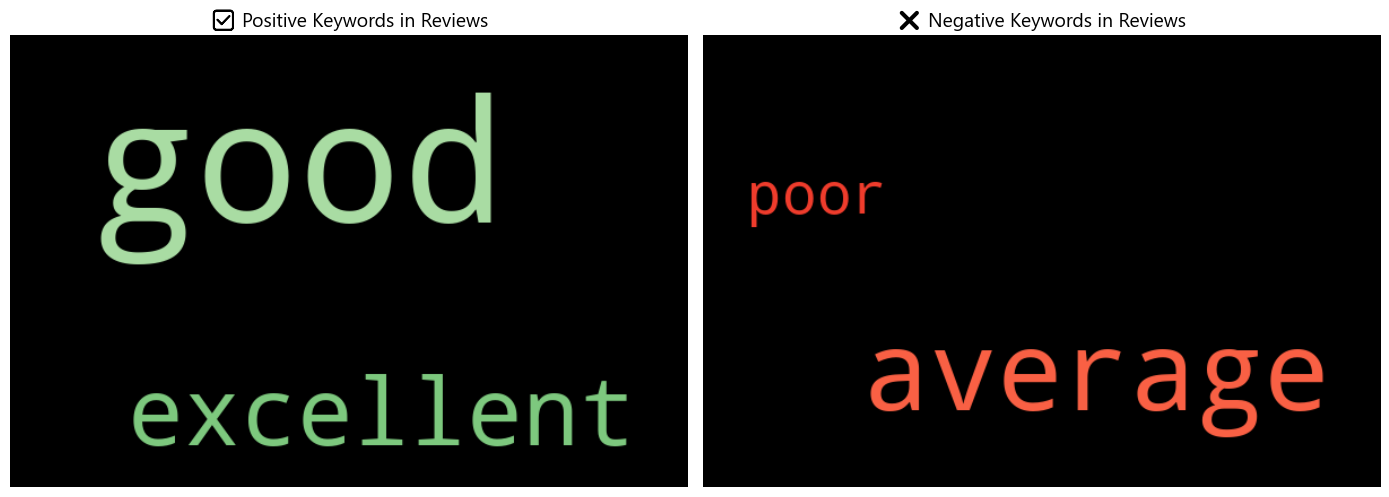

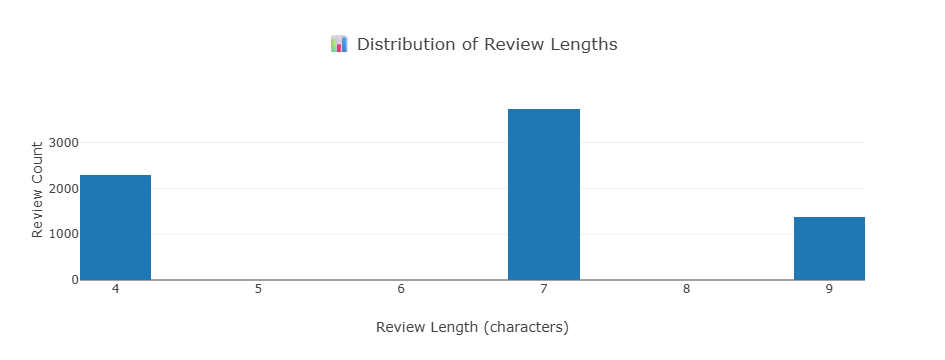

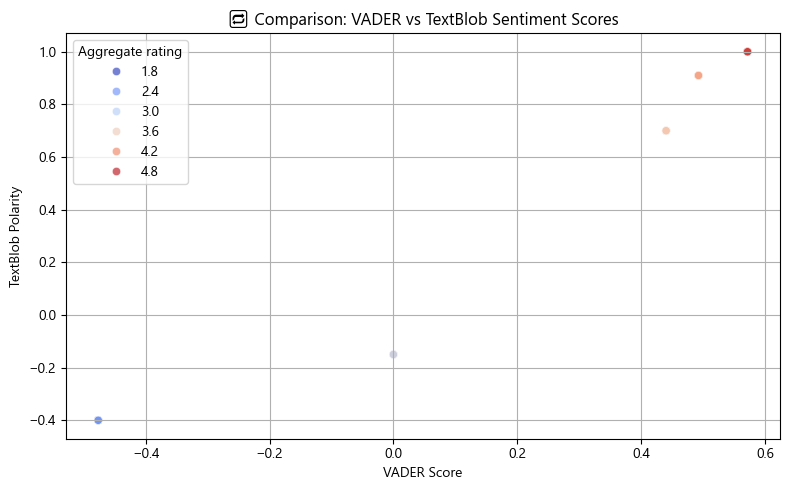

C:\Users\acer\AppData\Local\Temp\ipykernel_64812\2200742914.py:108: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




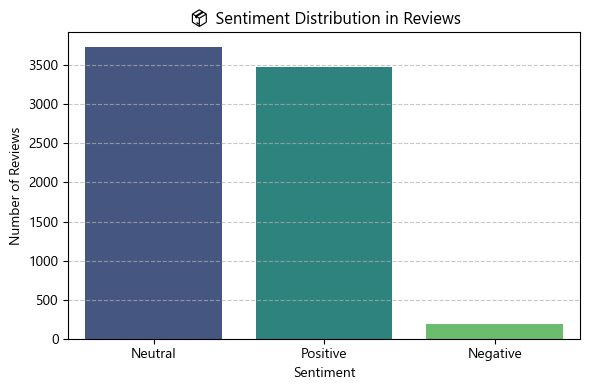

📈 Correlation between Aggregate Rating and VADER Score: 0.878


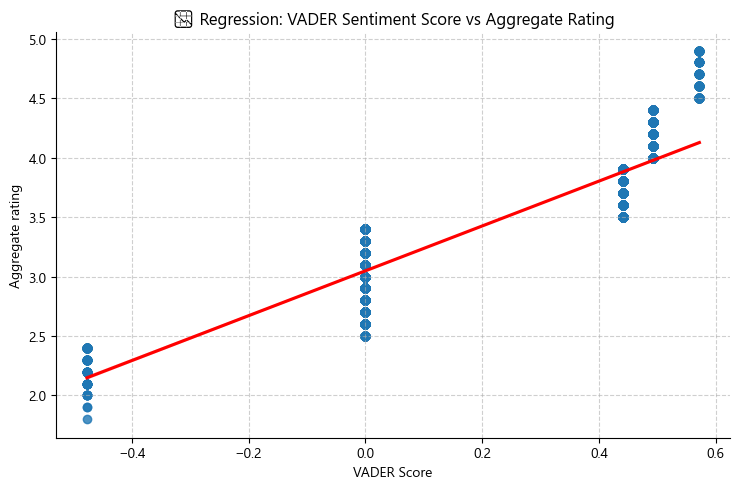

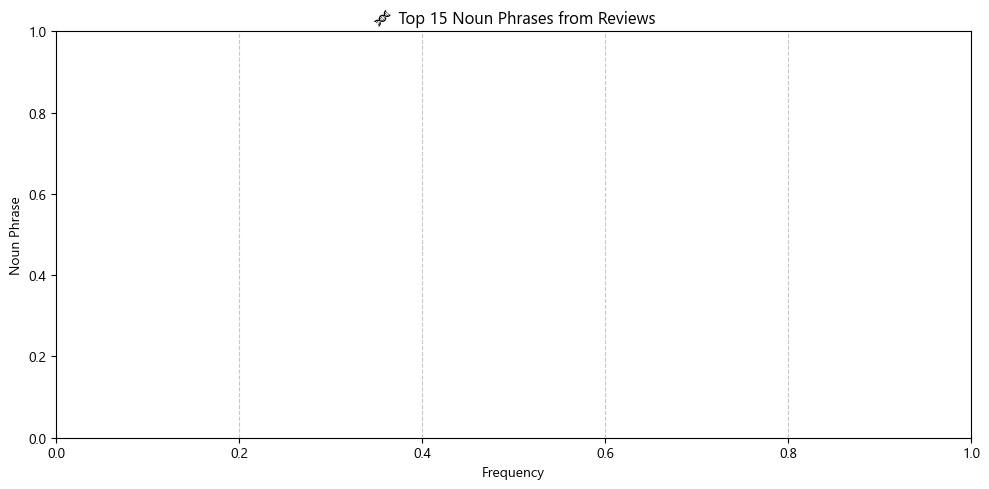

In [10]:
# 📦 Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob
import nltk
import plotly.express as px

# 🛠️ Optional Font Fix (Avoid emoji warnings in matplotlib)
plt.rcParams['font.family'] = 'Segoe UI Emoji'  # For emoji support; or use 'Arial Unicode MS'

# 📥 Download NLTK Resources
nltk.download('vader_lexicon')

# 🧠 Load spaCy model safely
try:
    import spacy
    nlp = spacy.load("en_core_web_sm")
except:
    import os
    os.system("python -m spacy download en_core_web_sm")
    import spacy
    nlp = spacy.load("en_core_web_sm")

# 📁 Load Dataset
df = pd.read_csv(r"C:\Users\acer\Downloads\Level 3 - Advanced Text, Correlation & Decision\Data Analysis Internship__Dataset__Cognifyz Technologies.csv")

# 🧹 Clean and Prepare Review Data
df_reviews = df[['Rating text', 'Aggregate rating']].dropna()
df_reviews = df_reviews[df_reviews['Rating text'].str.lower() != 'not rated'].copy()
df_reviews['Cleaned_Review'] = df_reviews['Rating text'].str.lower().str.strip()

# 🧠 Keyword Analysis
positive_words = ['excellent', 'very good', 'good', 'amazing', 'fantastic', 'delicious', 'great']
negative_words = ['poor', 'bad', 'worst', 'average', 'terrible', 'disappointed', 'not good']
all_words = ' '.join(df_reviews['Cleaned_Review']).split()
word_counts = Counter(all_words)

positive_freq = {word: count for word, count in word_counts.items() if word in positive_words}
negative_freq = {word: count for word, count in word_counts.items() if word in negative_words}

# 🎨 WordClouds
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
wc_pos = WordCloud(width=600, height=400, background_color='black', colormap='Greens').generate_from_frequencies(positive_freq)
plt.imshow(wc_pos, interpolation='bilinear')
plt.title("✅ Positive Keywords in Reviews", fontsize=14)
plt.axis('off')

plt.subplot(1, 2, 2)
wc_neg = WordCloud(width=600, height=400, background_color='black', colormap='Reds').generate_from_frequencies(negative_freq)
plt.imshow(wc_neg, interpolation='bilinear')
plt.title("❌ Negative Keywords in Reviews", fontsize=14)
plt.axis('off')

plt.tight_layout()
plt.show()

# 📏 Review Length Analysis
df_reviews['Review Length'] = df_reviews['Cleaned_Review'].apply(len)

fig = px.histogram(
    df_reviews, 
    x='Review Length', 
    nbins=15, 
    title='📊 Distribution of Review Lengths',
    color_discrete_sequence=['#1f77b4']
)
fig.update_layout(xaxis_title='Review Length (characters)', yaxis_title='Review Count')
fig.show()

# 🧠 Vader Sentiment Score
sid = SentimentIntensityAnalyzer()
df_reviews['VADER Score'] = df_reviews['Cleaned_Review'].apply(lambda x: sid.polarity_scores(x)['compound'])

# 🔬 TextBlob Sentiment Scores
df_reviews['TextBlob Polarity'] = df_reviews['Cleaned_Review'].apply(lambda x: TextBlob(x).sentiment.polarity)
df_reviews['TextBlob Subjectivity'] = df_reviews['Cleaned_Review'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

# 📊 Compare Vader vs TextBlob
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_reviews, 
    x='VADER Score', 
    y='TextBlob Polarity', 
    hue='Aggregate rating', 
    palette='coolwarm', 
    alpha=0.7
)
plt.title("🔁 Comparison: VADER vs TextBlob Sentiment Scores")
plt.grid(True)
plt.tight_layout()
plt.show()

# 🧠 Sentiment Labels
df_reviews['Sentiment Label'] = df_reviews['VADER Score'].apply(
    lambda x: 'Positive' if x > 0.2 else ('Negative' if x < -0.2 else 'Neutral')
)

# 📊 Sentiment Distribution
sentiment_counts = df_reviews['Sentiment Label'].value_counts()
plt.figure(figsize=(6,4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.title("📦 Sentiment Distribution in Reviews")
plt.ylabel("Number of Reviews")
plt.xlabel("Sentiment")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 📈 Sentiment vs Rating Correlation
correlation = df_reviews[['Aggregate rating', 'VADER Score']].corr().iloc[0,1].round(3)
print(f"📈 Correlation between Aggregate Rating and VADER Score: {correlation}")

sns.lmplot(
    data=df_reviews, 
    x='VADER Score', 
    y='Aggregate rating',
    aspect=1.5, height=5, line_kws={'color': 'red'}
)
plt.title("📉 Regression: VADER Sentiment Score vs Aggregate Rating")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 🧬 spaCy Noun Chunk Extraction
all_chunks = []

for doc in nlp.pipe(df_reviews['Cleaned_Review'].tolist(), batch_size=50):
    all_chunks.extend([chunk.text.lower() for chunk in doc.noun_chunks])

# 🔝 Top Noun Phrases
chunk_counts = Counter(all_chunks)
top_chunks = chunk_counts.most_common(15)

chunk_df = pd.DataFrame(top_chunks, columns=['Noun Chunk', 'Frequency'])

plt.figure(figsize=(10,5))
sns.barplot(data=chunk_df, y='Noun Chunk', x='Frequency', palette='magma')
plt.title("🧬 Top 15 Noun Phrases from Reviews")
plt.xlabel("Frequency")
plt.ylabel("Noun Phrase")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
